**Statistical test: BRAIN STRUCTURES**

In [51]:
config = {
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/",
    "output_dir": "data/results/whole_brain/eval_cl16/",
    "dataset_index_file_name": "whole_brain/dataset_index.csv",
    "metadata_file_name": "combined_metadata.csv",
    "results_path": "data/results/whole_brain/eval_cl16/retrieval.csv",
    "bias_columns": [
        "partition",
        "project",
        "field_strength",
        "manufacturer",
    ]
}


In [28]:
import pandas as pd
import os


# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))
if config.get("project_filter"):
    clinical_ds = clinical_ds.query(f"project == '{config['project_filter']}'").reset_index(drop=True)

# Load results:
results_df = pd.read_csv(config["results_path"]) 
# change column name query by GUID
results_df = results_df.rename(columns={"query": "GUID"})

# Merge on GUID
df = dataset = pd.merge(clinical_ds, results_df, on="GUID", how="inner")


In [45]:
import pandas as pd

# Step 1. Filter out subjects with < 6 scans
subject_counts = df["subject"].value_counts()
valid_subjects = subject_counts[subject_counts >= 6].index
df = df[df["subject"].isin(valid_subjects)].copy()

# Step 2. Define precision@5
def precision_at_5(row):
    subj = row["subject"]
    top_guids = [row["top1"], row["top2"], row["top3"], row["top4"], row["top5"]]

    retrieved_subjects = df.loc[df["GUID"].isin(top_guids), "subject"].values

    # Count how many retrieved are the same subject
    correct = sum(s == subj for s in retrieved_subjects)

    return correct / 5.0

df["precision5"] = df.apply(precision_at_5, axis=1)

# Step 3. Define success@5
def success_at_5(row):
    # The subject of the query
    subj = row["subject"]

    # Get the subjects of the top-5 retrieved GUIDs
    retrieved_subjects = df.loc[df["GUID"].isin(
        [row["top1"], row["top2"], row["top3"], row["top4"], row["top5"]]
    ), "subject"].values

    return int(subj in retrieved_subjects)

df["success5"] = df.apply(success_at_5, axis=1)



In [47]:
print(df.groupby("field_strength")[["precision5", "success5"]].mean())


                precision5  success5
field_strength                      
1.5               0.993894  0.997310
3.0               0.992615  0.998327


In [64]:
from scipy.stats import kruskal, mannwhitneyu
import itertools
import statsmodels.stats.multitest as smm
import numpy as np

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size for two independent samples.
    Returns delta and its magnitude interpretation.
    """
    nx, ny = len(x), len(y)
    # Pairwise comparisons
    more = sum(xi > yj for xi in x for yj in y)
    less = sum(xi < yj for xi in x for yj in y)
    delta = (more - less) / (nx * ny)

    # Interpret magnitude (Romano et al. 2006 thresholds)
    magnitude = "negligible"
    if abs(delta) >= 0.147:
        magnitude = "small"
    if abs(delta) >= 0.33:
        magnitude = "medium"
    if abs(delta) >= 0.474:
        magnitude = "large"

    return delta, magnitude


def post_hoc_statistical_bias(df, metric_to_use="precision5", column_name="field_strength"):
    res_test = {}
    # Group metric values by category
    grouped = {k: g[metric_to_use].dropna().values for k, g in df.groupby(column_name)}
    # Keep only non-empty groups
    grouped = {k: v for k, v in grouped.items() if len(v) > 0}

    if len(grouped) < 2:
        print(f"⚠️ Not enough non-empty groups for {column_name} ({metric_to_use})")
        return

    # Global Kruskal-Wallis
    stat, p = kruskal(*grouped.values())
    print(f"\nKruskal-Wallis ({column_name}, {metric_to_use}): p = {p:.4e}")

    # If significant, do post-hoc pairwise comparisons
    if p < 0.05:
        keys = list(grouped.keys())
        pairs = list(itertools.combinations(keys, 2))
        p_values, tested_pairs, deltas = [], [], []

        for a, b in pairs:
            group_a, group_b = grouped[a], grouped[b]
            if len(group_a) == 0 or len(group_b) == 0:
                continue

            # Mann-Whitney test
            _, p_val = mannwhitneyu(group_a, group_b, alternative="two-sided")
            p_values.append(p_val)
            tested_pairs.append((a, b))

            # Cliff’s delta
            delta, magnitude = cliffs_delta(group_a, group_b)
            deltas.append((delta, magnitude))

        if p_values:
            reject, p_corrected, _, _ = smm.multipletests(p_values, method="holm")
            for (a, b), p_val, p_corr, rej, (delta, mag) in zip(tested_pairs, p_values, p_corrected, reject, deltas):
                print(
                    f"  {a} vs {b}: raw p={p_val:.4e}, corrected p={p_corr:.4e}, "
                    f"reject={rej}, Cliff’s δ={delta:.3f} ({mag})"
                )

                res_test[f"{a} vs {b}"] = {"p-value": p_corr, "reject": rej, "d": delta, "magnitude": mag}
        else:
            print("⚠️ No valid pairs for post-hoc testing.")
        
    return res_test

bias_columns = config["bias_columns"]
metrics_to_use = ["precision5"]

res_test_list = []
for bias_column in bias_columns:
    for metric_to_use in metrics_to_use:
        print(f">>> {bias_column} <<<")
        print(df.groupby(bias_column)[[metric_to_use]].mean())
        res_test_list.append(post_hoc_statistical_bias(df, metric_to_use=metric_to_use, column_name=bias_column))
        print("----------------------------------------------------\n")

>>> partition <<<
           precision5
partition            
test         0.976780
train        0.999705

Kruskal-Wallis (partition, precision5): p = 1.2652e-127
  test vs train: raw p=1.2654e-127, corrected p=1.2654e-127, reject=True, Cliff’s δ=-0.045 (negligible)
----------------------------------------------------

>>> project <<<
         precision5
project            
adni       0.992769
aibl       0.966667
miriad     0.994556
oasis3     0.956322

Kruskal-Wallis (project, precision5): p = 6.4902e-45
  adni vs aibl: raw p=1.5896e-03, corrected p=6.3584e-03, reject=True, Cliff’s δ=0.151 (small)
  adni vs miriad: raw p=4.8018e-01, corrected p=9.6037e-01, reject=False, Cliff’s δ=0.003 (negligible)
  adni vs oasis3: raw p=1.4097e-45, corrected p=8.4580e-45, reject=True, Cliff’s δ=0.095 (negligible)
  aibl vs miriad: raw p=7.2672e-03, corrected p=2.1801e-02, reject=True, Cliff’s δ=-0.149 (small)
  aibl vs oasis3: raw p=7.1674e-01, corrected p=9.6037e-01, reject=False, Cliff’s δ=-0.047 

In [70]:
from tabulate import tabulate

def flatten_results(results_list):
    rows = []
    for group in results_list:
        for comparison, stats in group.items():
            rows.append([
                comparison,
                f"{stats['p-value']:.2e}",  # scientific notation
                "*" if stats["reject"] else "",
                f"{stats['d']:.3f}",
                stats["magnitude"]
            ])
    return rows

# Example usage
rows = flatten_results(res_test_list)
headers = ["Comparison", "p-value", "Reject H₀", "Cliff’s δ", "Magnitude"]
print(tabulate(rows, headers=headers, tablefmt="github"))


| Comparison                                    |   p-value | Reject H₀   |   Cliff’s δ | Magnitude   |
|-----------------------------------------------|-----------|-------------|-------------|-------------|
| test vs train                                 | 1.27e-127 | *           |      -0.045 | negligible  |
| adni vs aibl                                  | 0.00636   | *           |       0.151 | small       |
| adni vs miriad                                | 0.96      |             |       0.003 | negligible  |
| adni vs oasis3                                | 8.46e-45  | *           |       0.095 | negligible  |
| aibl vs miriad                                | 0.0218    | *           |      -0.149 | small       |
| aibl vs oasis3                                | 0.96      |             |      -0.047 | negligible  |
| miriad vs oasis3                              | 2.05e-10  | *           |       0.092 | negligible  |
| 1.5 vs 3.0                                    | 0.000395  | * 

/local/tmp.4965821/ipykernel_2755387/772598103.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x="field_strength", y="success5", data=df, ci=95)


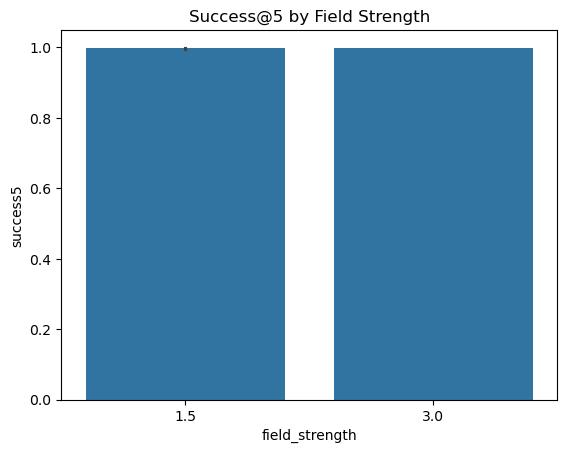

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.barplot(x="field_strength", y="success5", data=df, ci=95)
plt.title("Success@5 by Field Strength")
plt.show()
